#### Load the Data

In [4]:
import pandas as pd

# Load the preprocessed datasets
"""
X_train = pd.read_csv("preprocessed_data/X_train.csv")
X_test = pd.read_csv("preprocessed_data/X_test.csv")
y_train = pd.read_csv("preprocessed_data/y_train.csv")
y_test = pd.read_csv("preprocessed_data/y_test.csv")
"""
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the single processed file
data = pd.read_csv("preprocessed_data/processed_mushrooms.csv")

# 2. Separate X and y
X = data.drop('class', axis=1)
y = data['class']

# 3. Perform the split right before training
# Changing random_state will give you a different 'random' split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.model_selection import train_test_split

# Split training data into train + validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 6499
Testing set size: 1625


#### Implement the Logstic Regression Model & Hyper Parameter Tuning

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define hyperparameter search space for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10],  # Inverse of regularization strength
    'solver': ['lbfgs', 'liblinear']  # Solvers compatible with L2
}

# 2. Initialize Logistic Regression model
model = LogisticRegression(
    max_iter=500,
    random_state=42
)

# 3. Set up Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1  # Use all available CPU cores
)

# 4. Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

# 5. Retrieve the best model found by Grid Search
best_model = grid_search.best_estimator_

# 6. Replace original model with best model
model = best_model

# 7. Print best hyperparameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}


#### Training vs. Validation Error Curves

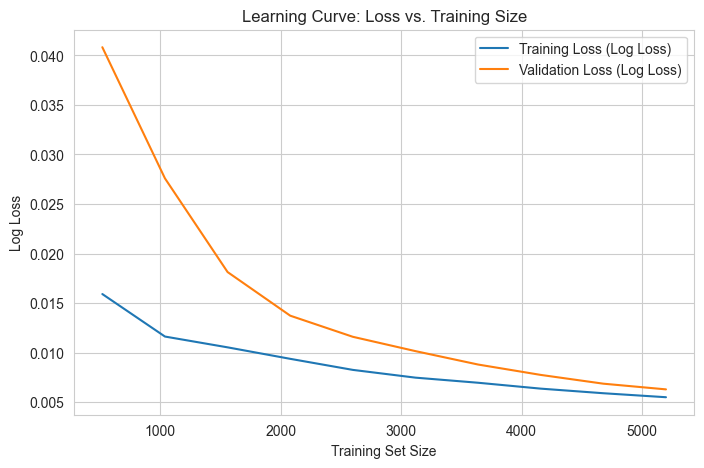

In [6]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(
    **grid_search.best_params_,
    max_iter=500,
    random_state=42
)

# Generate learning curve data using negative log loss
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

# Convert negative log loss to positive log loss
train_loss = -train_scores
val_loss = -val_scores

# Calculate the mean loss across all cross-validation folds
train_mean_loss = train_loss.mean(axis=1)
val_mean_loss = val_loss.mean(axis=1)

# Plot the training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean_loss, label="Training Loss (Log Loss)")
plt.plot(train_sizes, val_mean_loss, label="Validation Loss (Log Loss)")

# Set labels, title, and chart properties
plt.xlabel("Training Set Size")
plt.ylabel("Log Loss")
plt.title("Learning Curve: Loss vs. Training Size")
plt.legend()
plt.grid(True)
plt.show()

#### Train the Logistic Regression Model

In [44]:
# Fit the model to the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### Evaluate Performance

Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



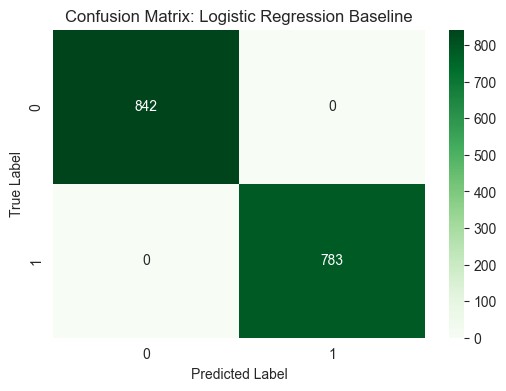

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Print accuracy and detailed classification metrics
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Logistic Regression Baseline')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

K-Fold Cross-Validation

In [46]:
from sklearn.model_selection import cross_validate

# Define the metrics you want to track
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Perform 5-fold cross-validation
results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)

# Convert to a DataFrame for a beautiful display in Jupyter
import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)

# Print the mean of the test metrics
print(f"Mean Test Accuracy: {results_df['test_accuracy'].mean():.4f}")
print(f"Mean Test F1-Score: {results_df['test_f1'].mean():.4f}")

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.018002,0.005000,1.000000,1.0,1.0000,1.0,1.000000,1.0,1.000000,1.0
1,0.016000,0.004000,1.000000,1.0,1.0000,1.0,1.000000,1.0,1.000000,1.0
2,0.017003,0.003998,1.000000,1.0,1.0000,1.0,1.000000,1.0,1.000000,1.0
3,0.018000,0.004585,0.997692,1.0,0.9984,1.0,0.996805,1.0,0.997602,1.0
4,0.018999,0.005001,1.000000,1.0,1.0000,1.0,1.000000,1.0,1.000000,1.0


Mean Test Accuracy: 0.9995
Mean Test F1-Score: 0.9995


Permutation Importance check(Robustness)

In [47]:
from sklearn.inspection import permutation_importance
import pandas as pd

# This will take a moment as it re-evaluates the model multiple times
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Organize the results
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(ascending=False, by='importance_mean')

# Print the top 10 features
print(importance_df.head(10))

                       feature  importance_mean  importance_std
20                 gill-size_n         0.194031        0.005620
32               stalk-shape_t         0.067385        0.003914
33                stalk-root_b         0.040738        0.002056
19              gill-spacing_w         0.023508        0.002871
63               ring-number_t         0.020677        0.002081
68         spore-print-color_h         0.017846        0.001805
37  stalk-surface-above-ring_k         0.017538        0.003440
54    stalk-color-below-ring_n         0.016677        0.001082
64                 ring-type_f         0.008123        0.000945
70         spore-print-color_n         0.007692        0.001746
